In [60]:
import numpy as np
from gpcam import GPOptimizer

import random

import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

import plotly.graph_objects as go

import os

from sklearn.neighbors import NearestNeighbors

import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

# Using Data Extracted from the Firedrake environment

In [61]:
# Load the saved data
data = np.load('dragon_complete_dataset_from_firedrake.npz')

# Extract all the data
vertices = data['vertices']                      # All mesh vertices (N, 3)
ground_truth = data['ground_truth']              # Ground truth values (N,)

# All Geodesics  # Load the geodesic distance matrix
all_geodesic_distances = np.load('/pscratch/sd/m/malghal/Riemannian-Gaussian-Processes/dragon_geodesic_matrix_full.npy')

print("Done")

Done


In [62]:
def verify_geodesics_from_training_points(train_idx, target_indices, vertices, ground_truth=None):    
    # Get the training point vertex index
    # train_vertex_idx = indices_train[train_idx]
    
    # Create the plot
    fig = go.Figure()
    
    # 1. Background dragon mesh (colored by ground truth)
    fig.add_trace(go.Scatter3d(
        x=vertices[:,0], 
        y=vertices[:,1], 
        z=vertices[:,2], 
        mode='markers', 
        marker=dict(
            size=2, 
            color=ground_truth if ground_truth is not None else 'lightgray',
            colorscale='plasma' if ground_truth is not None else None,
            opacity=0.2,
            showscale=True,
        ),
        name='Dragon Mesh',
        showlegend=False
    ))
    
    # # 2. Training point (large green diamond)
    # fig.add_trace(go.Scatter3d(
    #     x=[vertices[train_vertex_idx, 0]], 
    #     y=[vertices[train_vertex_idx, 1]], 
    #     z=[vertices[train_vertex_idx, 2]], 
    #     mode='markers',
    #     marker=dict(size=15, color='green', symbol='diamond'),
    #     showlegend=False
    # ))
    
    # 3. Target points with geodesic distances as color
    target_coords = vertices[target_indices]
    
    fig.add_trace(go.Scatter3d(
        x=target_coords[:,0], 
        y=target_coords[:,1], 
        z=target_coords[:,2], 
        mode='markers',
        marker=dict(
            size=8, 
            colorscale='Viridis',
            showscale=False,
        ),
        name='Target Points',
        showlegend=False
    ))
    
    # Layout
    fig.update_layout(
        scene=dict(
            xaxis_title='X', 
            yaxis_title='Y', 
            zaxis_title='Z',
            camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
        ),
        width=900, 
        height=700
    )

    
    fig.write_html(f"geodesic_verification_train_{train_idx}.html")
    fig.show()


    
# Test geodesics from a few training points
test_cases = [
    {
        'train_idx': 0,  # First training point
        'targets': [90000]  # Various distant points
    }
]

for case in test_cases:
    verify_geodesics_from_training_points(
        case['train_idx'], 
        case['targets'], 
        vertices, 
        ground_truth
    )

# GP Model Components

In [69]:
# Step 2 (Fixed): Define the basic GP components

def find_indices_by_lookup_efficient(target_points, all_points, tolerance=1e-10):    
    
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='kd_tree').fit(all_points)
    distances, indices = nbrs.kneighbors(target_points)
    
    return indices.flatten()
    

def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter. Identifies the cutoff after which the covariance becomes 0 when beta=0
    beta: shape parameter. 0 results in a square-like function, larger values cause faster decay
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        #beta = 0.1
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

    
def bump_kernel_geodesic(x1, x2, hps):
        
     # Find indices of x1 and x2 in the full mesh
    x1_indices = find_indices_by_lookup_efficient(x1, vertices)
    x2_indices = find_indices_by_lookup_efficient(x2, vertices)
    
    # Extract geodesic distances from training points to x1 and x2 locations
    d1 = all_geodesic_distances[np.ix_(indices_train, x1_indices)]  # Shape: (n_train, len(x1))
    d2 = all_geodesic_distances[np.ix_(indices_train, x2_indices)]  # Shape: (n_train, len(x2))
    
    # Compute bump functions
    # gs1: bump function values for x1 locations
    gs1 = bump(d1, hps[1], hps[2], 1.)  # Shape: (n_train, len(x1))
    
    # gs2: bump function values for x2 locations
    gs2 = bump(d2, hps[1], hps[2], 1.)  # Shape: (n_train, len(x2))
    
    # Compute kernel matrix: K[i,j] = sum over training points
    G = gs1.T @ gs2  # Shape: (len(x1), len(x2))
    
    # Scale by hyperparameters
    kernel_matrix = hps[0] * G / float(len(indices_train))
    
    return kernel_matrix

def my_noise(x, hps):
    s = np.ones(len(x)) * hps[3]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * hps[4]
    return m

# Running One GP model training

In [72]:
np.random.seed(2355)

indices_train = np.random.choice(len(vertices), size=51, replace=False)

x_train = vertices[indices_train]
y_train = ground_truth[indices_train]

print("Training Shape: ", x_train.shape)

# Define Test Data

n_test_subset = 5000  # Manageable number for testing
subset_indices = np.random.choice(len(vertices), size=n_test_subset, replace=False)

x_test = vertices[subset_indices]
y_test = ground_truth[subset_indices]

print("Testing Shape: ", x_test.shape)


Training Shape:  (51, 3)
Testing Shape:  (5000, 3)


In [77]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# Define hyperparameter bounds
bounds = np.empty((3, 2))
bounds[0] = np.array([1, 1000])      # sigma_f: signal variance      
bounds[1] = np.array([0.2, 10])         # length_scale: bump radius
bounds[2] = np.array([0.01, 500])      #  beta
#bounds[3] = np.array([1e-10, 1e-9])   # sigma_n: noise variance
#bounds[4] = np.array([-1, 1])        # mean: constant mean value

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_kernel_geodesic,
                     #prior_mean_function=my_mean, 
                     #noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")


# Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='mcmc', max_iter=6000)


# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")



Initial hyperparameters: [500.5     5.1   250.005]
Initial log likelihood: -12128.543526
Final hyperparameters:   [8.71207225e+02 3.22907909e-01 8.23531949e+01]
Final log likelihood:    -85.48


RMSE: 2.0717518576616274 %


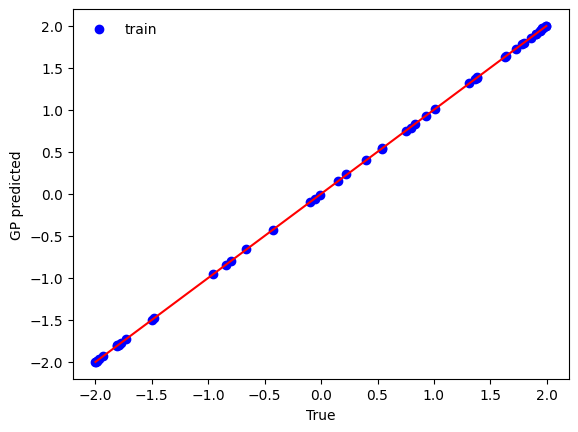

In [78]:
f_train = my_gpo.posterior_mean(x_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(x_train,y_train)*100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 692.7147285990399 %


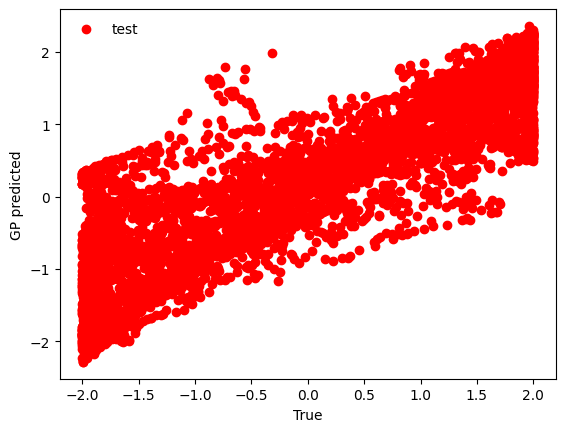

In [79]:
f = my_gpo.posterior_mean(x_test)["m(x)"]

print('RMSE:', my_gpo.rmse(x_test,y_test)*100/np.mean(y_test),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
#plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [76]:
fig = go.Figure(data=[go.Scatter3d(
                            x=x_test[:,0],
                            y=x_test[:,1],
                            z=x_test[:,2], 
                            mode='markers', 
                            marker=dict(size=5, color=f, colorscale='plasma',opacity=0.8,
                                        #cmin= np.min(my_kernel_plot),
                                        #cmax= np.max(my_kernel_plot),
                                       showscale=True,  # This adds the colorbar
                                      colorbar=dict(thickness=15,
                                                    len=0.7)),
                            name="Test Points"  # Add name for legend
                        )])

# Add x_train data with black colors
fig.add_trace(go.Scatter3d(
    x=x_train[:, 0],
    y=x_train[:, 1],
    z=x_train[:, 2], 
    mode='markers',
    marker=dict(
        size=5,  # Same size as test points
        color='black',  # Black color
        opacity=0.8,
        line=dict(width=0.5, color='gray')  # Optional: add gray border
    ),
    name="Train Points"
))

# Highlight the first point
fig.add_trace(go.Scatter3d(
    x=[x_test[0, 0]],
    y=[x_test[0, 1]],
    z=[x_test[0, 2]], 
    mode='markers+text',
    marker=dict(
        size=15,  # Larger size
        color='red',  # Different color
        symbol='diamond',  # Different shape
        line=dict(width=3, color='white')  # White border
    ),
    text=["First Point"],
    textposition="top center",
    textfont=dict(size=14, color='white'),
    name="First Point"
))

fig.update_layout(
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

In [22]:
# import matplotlib.pyplot as plt
# import numpy as np

# print("🔍 Creating variogram for training points")


# # Method 1: Extract training point to training point distances
# train_to_train_distances = train_to_all_geodesics[:, indices_train]  # Shape: (51, 51)

# # Calculate pairwise differences in ground truth for training points
# delta_y_train = np.abs(np.subtract.outer(y_train, y_train))

# # Create variogram plot for training points
# plt.figure(figsize=(12, 8))

# # Plot 1: Training point variogram
# plt.subplot(2, 2, 1)
# # Remove diagonal (distance=0, difference=0)
# mask = ~np.eye(len(y_train), dtype=bool)
# plt.scatter(train_to_train_distances[mask], delta_y_train[mask], 
#            alpha=0.6, s=20, color='blue')
# plt.xlabel("Geodesic Distance")
# plt.ylabel("|y_i - y_j|")
# plt.title(f"Training Points Variogram ({len(y_train)} points)")
# plt.grid(True, alpha=0.3)

# print(f"Training point pairs: {mask.sum()}")

# Making several trials with different training size

In [11]:
import numpy as np
import random
import json
from tqdm import tqdm


In [14]:
# def generate_training_configurations():
#     # Configuration
#     training_sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 
#                      550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]
#     n_trials = 100
#     total_data_points = 100179
    
#     # Generate 100 random seeds
#     np.random.seed(42)
#     random_seeds = np.random.randint(1, 100000, size=n_trials)
    
#     # Generate single test set (NEW LINE)
#     np.random.seed(9999)
#     test_indices = np.random.choice(total_data_points, size=5000, replace=False).tolist()
    
#     # Structure to store all configurations
#     training_configs = {
#         "test_indices": test_indices,  # Add test indices to JSON
#         "training_configurations": {}
#     }
    
#     print(f"Generating configurations for {len(training_sizes)} training sizes...")
#     print(f"Each size will have {n_trials} trials")
    
#     for train_size in tqdm(training_sizes, desc="Training sizes"):
#         train_size_configs = []
        
#         for trial_idx in tqdm(range(n_trials), desc=f"Size {train_size}", leave=False):
#             seed = int(random_seeds[trial_idx])
            
#             # Set seed and generate indices
#             np.random.seed(seed)
#             random.seed(seed)
            
#             # Generate training indices (same as before - no overlap checking)
#             indices_train = random.sample(range(total_data_points), train_size)
            
#             # Store configuration for this trial
#             trial_config = {
#                 "seed": seed,
#                 "indices_train": indices_train
#             }
            
#             train_size_configs.append(trial_config)
        
#         # Store all trials for this training size
#         training_configs["training_configurations"][str(train_size)] = train_size_configs
    
#     return training_configs

# # Generate the configurations
# print("Generating training configurations...")
# training_configs = generate_training_configurations()

# # Save to JSON file
# with open('dragon_example_training_configurations.json', 'w') as f:
#     json.dump(training_configs, f, indent=2)

# print(f"✅ Saved training configurations to 'training_configurations.json'")
# print(f"📊 Test indices: {len(training_configs['test_indices'])}")
# print(f"📊 Training sizes: {len(training_configs['training_configurations'])}")
# print(f"🎯 Total trials: {sum(len(trials) for trials in training_configs['training_configurations'].values())}")

In [32]:
def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    x_test = vertices[test_indices]
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    x_train = vertices[indices_train]
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed

def train_gp_model(x_train, y_train):
    """Train GP model with your existing setup"""
    # Define hyperparameter bounds
    bounds = np.empty((3, 2))
    bounds[0] = np.array([1e-3, 100])      # sigma_f: signal variance      
    bounds[1] = np.array([0.01, 1.5])      # length_scale: bump radius
    bounds[2] = np.array([0.1, 10])        # beta
    
    # Initial hyperparameters (middle of bounds)
    init_hps = np.mean(bounds, axis=1)
    
    # Initialize GPOptimizer
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_kernel_geodesic)
    
    # Train the GP model
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='mcmc', 
                 max_iter=4000)
    
    return my_gpo


def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """Run all GP experiments and save results incrementally"""
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = 'dragon_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = 'dragon_example_gp_experiment_results.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    #print("Loading test data...")
    x_test, y_test = get_test_data(configs, vertices, ground_truth)
    #print(f"Test data shape: {x_test.shape}")
    
    # Get all training sizes
    training_sizes = list(configs['training_configurations'].keys())
    training_sizes = [int(size) for size in training_sizes]
    training_sizes.sort()
    
    #print(f"Training sizes: {training_sizes}")
    #print(f"Starting experiments...")
    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        
        trials = configs['training_configurations'][str(train_size)]
        
        #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
        for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):
    
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"  ⏭️ Skipping trial {trial_idx} (already completed)")
                continue
            
            try:
                # Get training data for this trial
                x_train, y_train, seed = get_training_data(configs, train_size, trial_idx, vertices, ground_truth)
                
                # Train GP model
                my_gpo = train_gp_model(x_train, y_train)
                
                # Calculate training RMSE
                train_rmse = my_gpo.rmse(x_train, y_train)
                
                # Calculate testing RMSE
                test_rmse = my_gpo.rmse(x_test, y_test)
                
                # Get final hyperparameters and log likelihood
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                
                # Save after each trial ✅
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"  Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} ✅ Saved")
                
            except Exception as e:
                print(f"  ❌ Trial {trial_idx} failed: {str(e)}")
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("🚀 Starting GP experiments...")
print("="*60)

# # Check if required variables exist
# try:
#     print(f"Vertices shape: {vertices.shape}")
#     print(f"Ground truth shape: {ground_truth.shape}")
# except NameError:
#     print("❌ Error: vertices and ground_truth variables not found!")
#     print("Make sure you have loaded your data first.")
#     exit()

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"🎉 Completed! Total experiments: {len(results)}")

🚀 Starting GP experiments...
Loading configurations...
📂 Loaded 249 existing results

=== Training Size: 50 ===


Size 50: 100%|██████████| 30/30 [00:00<00:00, 94324.68it/s]


  ⏭️ Skipping trial 0 (already completed)
  ⏭️ Skipping trial 1 (already completed)
  ⏭️ Skipping trial 2 (already completed)
  ⏭️ Skipping trial 3 (already completed)
  ⏭️ Skipping trial 4 (already completed)
  ⏭️ Skipping trial 5 (already completed)
  ⏭️ Skipping trial 6 (already completed)
  ⏭️ Skipping trial 7 (already completed)
  ⏭️ Skipping trial 8 (already completed)
  ⏭️ Skipping trial 9 (already completed)
  ⏭️ Skipping trial 10 (already completed)
  ⏭️ Skipping trial 11 (already completed)
  ⏭️ Skipping trial 12 (already completed)
  ⏭️ Skipping trial 13 (already completed)
  ⏭️ Skipping trial 14 (already completed)
  ⏭️ Skipping trial 15 (already completed)
  ⏭️ Skipping trial 16 (already completed)
  ⏭️ Skipping trial 17 (already completed)
  ⏭️ Skipping trial 18 (already completed)
  ⏭️ Skipping trial 19 (already completed)
  ⏭️ Skipping trial 20 (already completed)
  ⏭️ Skipping trial 21 (already completed)
  ⏭️ Skipping trial 22 (already completed)
  ⏭️ Skipping trial 2

Size 100: 100%|██████████| 30/30 [00:00<00:00, 97769.32it/s]


  ⏭️ Skipping trial 0 (already completed)
  ⏭️ Skipping trial 1 (already completed)
  ⏭️ Skipping trial 2 (already completed)
  ⏭️ Skipping trial 3 (already completed)
  ⏭️ Skipping trial 4 (already completed)
  ⏭️ Skipping trial 5 (already completed)
  ⏭️ Skipping trial 6 (already completed)
  ⏭️ Skipping trial 7 (already completed)
  ⏭️ Skipping trial 8 (already completed)
  ⏭️ Skipping trial 9 (already completed)
  ⏭️ Skipping trial 10 (already completed)
  ⏭️ Skipping trial 11 (already completed)
  ⏭️ Skipping trial 12 (already completed)
  ⏭️ Skipping trial 13 (already completed)
  ⏭️ Skipping trial 14 (already completed)
  ⏭️ Skipping trial 15 (already completed)
  ⏭️ Skipping trial 16 (already completed)
  ⏭️ Skipping trial 17 (already completed)
  ⏭️ Skipping trial 18 (already completed)
  ⏭️ Skipping trial 19 (already completed)
  ⏭️ Skipping trial 20 (already completed)
  ⏭️ Skipping trial 21 (already completed)
  ⏭️ Skipping trial 22 (already completed)
  ⏭️ Skipping trial 2

...

  ⏭️ Skipping trial 0 (already completed)
  ⏭️ Skipping trial 1 (already completed)
  ⏭️ Skipping trial 2 (already completed)
  ⏭️ Skipping trial 3 (already completed)
  ⏭️ Skipping trial 4 (already completed)
  ⏭️ Skipping trial 5 (already completed)
  ⏭️ Skipping trial 6 (already completed)
  ⏭️ Skipping trial 7 (already completed)
  ⏭️ Skipping trial 8 (already completed)
  ⏭️ Skipping trial 9 (already completed)
  ⏭️ Skipping trial 10 (already completed)
  ⏭️ Skipping trial 11 (already completed)
  ⏭️ Skipping trial 12 (already completed)
  ⏭️ Skipping trial 13 (already completed)
  ⏭️ Skipping trial 14 (already completed)
  ⏭️ Skipping trial 15 (already completed)
  ⏭️ Skipping trial 16 (already completed)
  ⏭️ Skipping trial 17 (already completed)
  ⏭️ Skipping trial 18 (already completed)
  ⏭️ Skipping trial 19 (already completed)
  ⏭️ Skipping trial 20 (already completed)
  ⏭️ Skipping trial 21 (already completed)
  ⏭️ Skipping trial 22 (already completed)
  ⏭️ Skipping trial 2

Size 450:   0%|          | 0/30 [00:00<?, ?it/s]

  ⏭️ Skipping trial 0 (already completed)
  ⏭️ Skipping trial 1 (already completed)
  ⏭️ Skipping trial 2 (already completed)
  ⏭️ Skipping trial 3 (already completed)
  ⏭️ Skipping trial 4 (already completed)
  ⏭️ Skipping trial 5 (already completed)
  ⏭️ Skipping trial 6 (already completed)
  ⏭️ Skipping trial 7 (already completed)
  ⏭️ Skipping trial 8 (already completed)


Size 450:  30%|███       | 9/30 [00:07<00:18,  1.15it/s]


KeyboardInterrupt: 

## Analyze Results

In [36]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def load_and_process_results(filename):
    """Load results and organize by training size"""
    with open(filename, 'r') as f:
        results = json.load(f)
    
    # Organize results by training size
    organized_results = defaultdict(lambda: {'train_rmse': [], 'test_rmse': []})
    
    for result in results:
        # Skip failed trials
        if result.get('status') == 'failed' or 'error' in result:
            continue
            
        train_size = result['training_size']
        train_rmse = result['train_rmse']
        test_rmse = result['test_rmse']
        
        organized_results[train_size]['train_rmse'].append(train_rmse)
        organized_results[train_size]['test_rmse'].append(test_rmse)
    
    return organized_results

def calculate_stats(organized_results):
    """Calculate mean and standard error for each training size"""
    stats = {}
    
    for train_size, rmse_data in organized_results.items():
        train_rmses = np.array(rmse_data['train_rmse'])
        test_rmses = np.array(rmse_data['test_rmse'])
        
        stats[train_size] = {
            'train_mean': np.mean(train_rmses),
            'train_sem': np.std(train_rmses) / np.sqrt(len(train_rmses)),  # Standard error of mean
            'test_mean': np.mean(test_rmses),
            'test_sem': np.std(test_rmses) / np.sqrt(len(test_rmses)),
            'n_trials': len(train_rmses)
        }
    
    return stats

# Load your main results
results_file1 = '/pscratch/sd/m/malghal/Riemannian-Gaussian-Processes/dragon_example_manifold_matern_gp_experiment_results.json'
results1 = load_and_process_results(results_file1)
stats1 = calculate_stats(results1)

# Load comparison results (replace with your second file)
results_file2 = '/pscratch/sd/m/malghal/Flexible_kernels/dragon_example_gp_experiment_results.json'  # Replace with actual filename
results2 = load_and_process_results(results_file2)
stats2 = calculate_stats(results2)

print("📊 Results Summary:")
print("=" * 50)
print("Method 1 (Manifold Matern):")
for train_size in sorted(stats1.keys()):
    s = stats1[train_size]
    print(f"Size {train_size:3d}: Test RMSE = {s['test_mean']:.4f} ± {s['test_sem']:.4f} ({s['n_trials']} trials)")

print("\nMethod 2 (Comparison):")
for train_size in sorted(stats2.keys()):
    s = stats2[train_size]
    print(f"Size {train_size:3d}: Test RMSE = {s['test_mean']:.4f} ± {s['test_sem']:.4f} ({s['n_trials']} trials)")


📊 Results Summary:
Method 1 (Manifold Matern):
Size  50: Test RMSE = 0.4975 ± 0.0130 (30 trials)
Size 100: Test RMSE = 0.2834 ± 0.0065 (30 trials)
Size 150: Test RMSE = 0.2192 ± 0.0056 (30 trials)
Size 200: Test RMSE = 0.1755 ± 0.0043 (21 trials)

Method 2 (Comparison):
Size  50: Test RMSE = 1.1569 ± 0.0804 (30 trials)
Size 100: Test RMSE = 0.5892 ± 0.0190 (30 trials)
Size 150: Test RMSE = 0.4763 ± 0.0146 (30 trials)
Size 200: Test RMSE = 0.4131 ± 0.0074 (30 trials)
Size 250: Test RMSE = 0.3785 ± 0.0043 (30 trials)
Size 300: Test RMSE = 0.3646 ± 0.0041 (30 trials)
Size 350: Test RMSE = 0.3538 ± 0.0035 (30 trials)
Size 400: Test RMSE = 0.3501 ± 0.0032 (30 trials)
Size 450: Test RMSE = 0.3384 ± 0.0021 (9 trials)


In [48]:
def results_to_dataframe(filename):
    """Convert JSON results to pandas DataFrame"""
    
    # Load the raw JSON data
    with open(filename, 'r') as f:
        raw_results = json.load(f)
    
    # Convert to DataFrame
    df = pd.DataFrame(raw_results)
    
    return df

# Convert your results to DataFrame
results_file1 = '/pscratch/sd/m/malghal/Riemannian-Gaussian-Processes/dragon_example_manifold_matern_gp_experiment_results.json'
df1 = results_to_dataframe(results_file1)

test_rmse_50 = df1[df1['training_size'] == 50]['test_rmse']


np.mean(test_rmse_50)

np.float64(0.49750380334311023)

In [49]:
df1

,training_size,trial,seed,train_rmse,test_rmse
0,50,0,15796,3.490797e-15,0.584181
1,50,1,861,2.770266e-15,0.496577
2,50,2,76821,1.214117e-14,0.437258
3,50,3,54887,2.981895e-15,0.420298
4,50,4,6266,9.043111e-15,0.493177
...,...,...,...,...,...
141,250,21,53708,1.127170e-13,0.171205
142,250,22,85306,1.332166e-13,0.182874
143,250,23,28694,1.373657e-13,0.166461
144,250,24,71933,6.190099e-14,0.138994


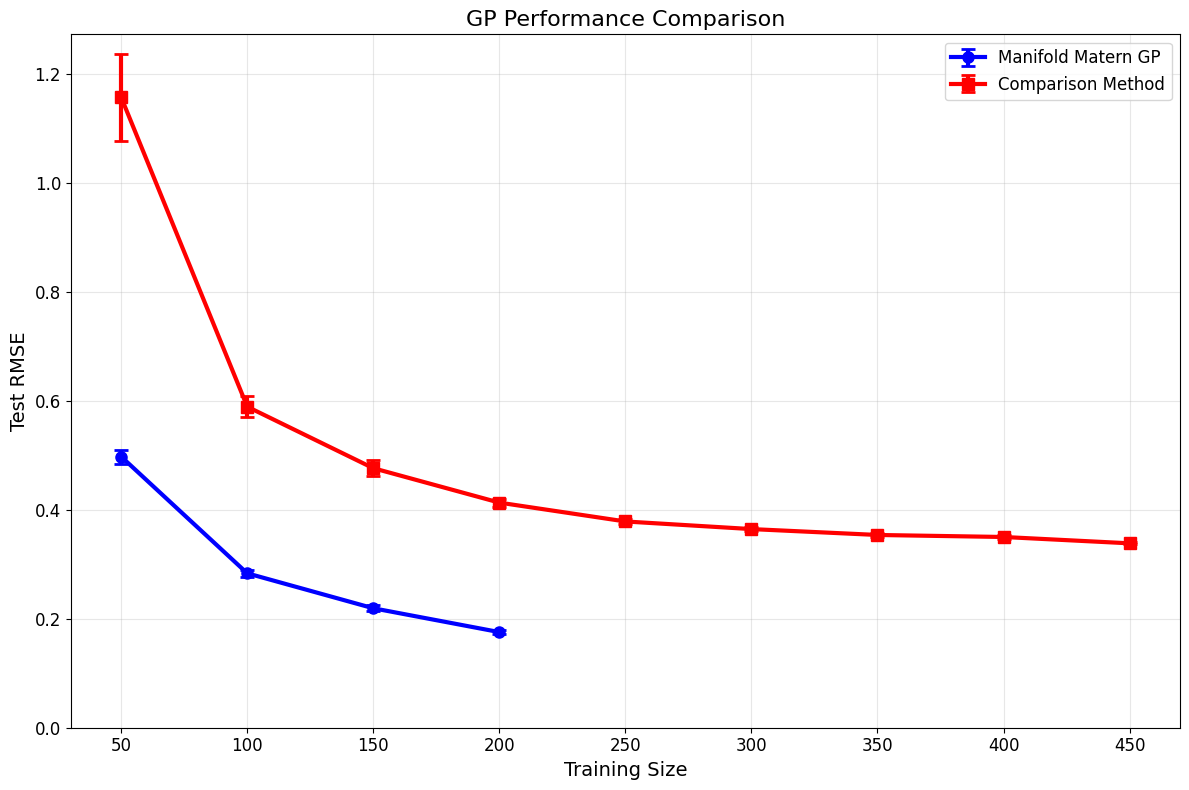

In [38]:
# Create linear scale plot
plt.figure(figsize=(12, 8))

# Extract data for both methods
train_sizes1 = sorted(stats1.keys())
test_means1 = [stats1[size]['test_mean'] for size in train_sizes1]
test_sems1 = [stats1[size]['test_sem'] for size in train_sizes1]

train_sizes2 = sorted(stats2.keys())
test_means2 = [stats2[size]['test_mean'] for size in train_sizes2]
test_sems2 = [stats2[size]['test_sem'] for size in train_sizes2]

# Plot both methods
plt.errorbar(train_sizes1, test_means1, yerr=test_sems1, 
            marker='o', linewidth=3, capsize=5, capthick=2,
            label='Manifold Matern GP', color='blue', markersize=8)

plt.errorbar(train_sizes2, test_means2, yerr=test_sems2,
            marker='s', linewidth=3, capsize=5, capthick=2,
            label='Comparison Method', color='red', markersize=8)

plt.xlabel('Training Size', fontsize=14)
plt.ylabel('Test RMSE', fontsize=14)
plt.title('GP Performance Comparison', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Set y-axis to start from 0 for better comparison
plt.ylim(0, max(test_means2) * 1.1)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()